### Get Meta and Google Trends data

In [3]:
!python scripts/get_data.py

Available regions in MA:
- key=2228, name=Taza-Al Hoceima-Taounate
- key=4388, name=Souss-Massa-Drâa
- key=4387, name=Dakhla-Oued Ed-Dahab
- key=4389, name=Gharb-Chrarda-Béni Hssen
- key=4393, name=Tadla-Azilal
- key=2206, name=Grand Casablanca
- key=4392, name=Doukkala-Abda
- key=4390, name=Chaouia-Ouardigha
- key=2232, name=Laâyoune-Boujdour-Sakia El Hamra
- key=2226, name=Tangier-Tetouan
- key=2223, name=Rabat-Salé-Zemmour-Zaer
- key=2212, name=Fès-Boulemane
- key=2230, name=Guelmim-Es Semara
- key=4391, name=Oriental
- key=2218, name=Marrakesh-Tensift-El Haouz
- key=2219, name=Meknès-Tafilalet
Sample region rows:
{'region_key': '2228', 'region_name': 'Taza-Al Hoceima-Taounate', 'gender': 'ALL', 'dau': 408375, 'mau_mid': 619300.0, 'mau_low': 569100, 'mau_high': 669500}
{'region_key': '2228', 'region_name': 'Taza-Al Hoceima-Taounate', 'gender': 'F', 'dau': 268764, 'mau_mid': 396000.0, 'mau_low': 363900, 'mau_high': 428100}
{'region_key': '2228', 'region_name': 'Taza-Al Hoceima-Taouna

### Get census data, clean and merge

In [6]:
%run scripts/clean_merge.py


Loading Meta + Google Trends data...
df_wide columns: ['Unnamed: 0', 'RegionCode', 'RegionName', 'DailyActiveUsers_ALL', 'DailyActiveUsers_F', 'DailyActiveUsers_M', 'MonthlyActiveUsersMid_ALL', 'MonthlyActiveUsersMid_F', 'MonthlyActiveUsersMid_M', 'FMIndex_Monthly_MAU', 'FMIndex_Daily_DAU', 'RegionName_norm', 'GT_FM_index', 'ADM1_target_norm']
Aggregated Meta + Trends indices at ADM1 level:
             ADM1_target_norm  FMIndex_Monthly_MAU  GT_FM_index
0        beni mellal-khenifra             1.574465     0.705224
1        dakhla-oued ed dahab             1.745686          NaN
2                  fes-meknes             1.419554     0.969511
3     grand casablanca-settat             1.457374     0.956236
4           guelmim-oued noun             1.389837     0.427481
5     laayoune-sakia el hamra             1.335382          NaN
6              marrakech-safi             1.469544     1.014110
7                    oriental             1.338007     0.790323
8          rabat-sale-kenitra 

In [8]:
import geopandas as gpd

gdf = gpd.read_file("data/gdf_gddi_26-11-25.geojson")
gdf.head()


,ADM1_FR,ADM1_FR_norm,ADM1_target_norm,FMIndex_Monthly_MAU,GT_FM_index,Region_norm,TotalPopulation,MalePopulation,FemalePopulation,geometry
0,Béni Mellal-Khénifra,beni mellal-khenifra,beni mellal-khenifra,1.574465,0.705224,beni mellal-khenifra,2510799.0,1227780.711,1283018.289,"POLYGON ((-5.77804 32.12795, -5.78022 32.12623..."
1,Drâa-Tafilalet,draa-tafilalet,None,NaN,NaN,draa-tafilalet,1643144.0,808426.848,834717.152,"POLYGON ((-5.01019 30.07653, -5.02636 30.06821..."
2,Fès-Meknès,fes-meknes,fes-meknes,1.419554,0.969511,fes-meknes,4436873.0,2205125.881,2231747.119,"POLYGON ((-3.51158 33.89488, -3.51065 33.89469..."
3,Grand Casablanca-Settat,grand casablanca-settat,grand casablanca-settat,1.457374,0.956236,grand casablanca-settat,7651096.0,3817896.904,3833199.096,"POLYGON ((-8.04935 32.78295, -8.04968 32.78263..."
4,Guelmim-Oued Noun,guelmim-oued noun,guelmim-oued noun,1.389837,0.427481,guelmim-oued noun,417663.0,205907.859,211755.141,"POLYGON ((-9.16852 28.69376, -9.13271 28.69418..."


### Run Models

In [10]:
%run scripts/run_models.py

Loading base GeoDataFrame from: /home/alina/DPA/P143-UN-WOMEN-big-data-gender-and-the-sdgs-morocco/DIGITAL_GENDER/data/gdf_gddi_26-11-25.geojson
Columns in gdf: ['ADM1_FR', 'ADM1_FR_norm', 'ADM1_target_norm', 'FMIndex_Monthly_MAU', 'GT_FM_index', 'Region_norm', 'TotalPopulation', 'MalePopulation', 'FemalePopulation', 'geometry']

Loading SDG 17.8.1 (Internet usage) for national F/M ratio...
Internet usage (Morocco, 2021)
  Female: 86.4
  Male:   89.9
  Both:   88.1
  National Internet F/M ratio: 0.961

Loading SDG 5.b.1 (Mobile phone usage) for national F/M ratio...
Mobile phone use (Morocco, 2023)
  Female: 96.5
  Male:   97.0
  Both:   96.8
  National Mobile F/M ratio: 0.995

Preview of final indices:
                   ADM1_FR  FMIndex_Monthly_MAU  GT_FM_index  FM_final  \
0     Béni Mellal-Khénifra             1.574465     0.705224  1.116602   
1           Drâa-Tafilalet                  NaN          NaN       NaN   
2               Fès-Meknès             1.419554     0.969511  0.9

### Plot maps

Loading base GeoJSON from: /home/alina/DPA/P143-UN-WOMEN-big-data-gender-and-the-sdgs-morocco/DIGITAL_GENDER/data/gdf_gddi_26-11-25.geojson
Loading indices CSV from: /home/alina/DPA/P143-UN-WOMEN-big-data-gender-and-the-sdgs-morocco/DIGITAL_GENDER/results/gddi_indices_26-11-25.csv
Merged GeoDataFrame columns:
['ADM1_FR', 'ADM1_FR_norm', 'ADM1_target_norm', 'Region_norm', 'TotalPopulation', 'MalePopulation', 'FemalePopulation', 'geometry', 'FMIndex_Monthly_MAU', 'GT_FM_index', 'FM_final', 'FM_mobile_final']
Saving Facebook vs Trends map to: /home/alina/DPA/P143-UN-WOMEN-big-data-gender-and-the-sdgs-morocco/DIGITAL_GENDER/results/map_fb_vs_trends.png


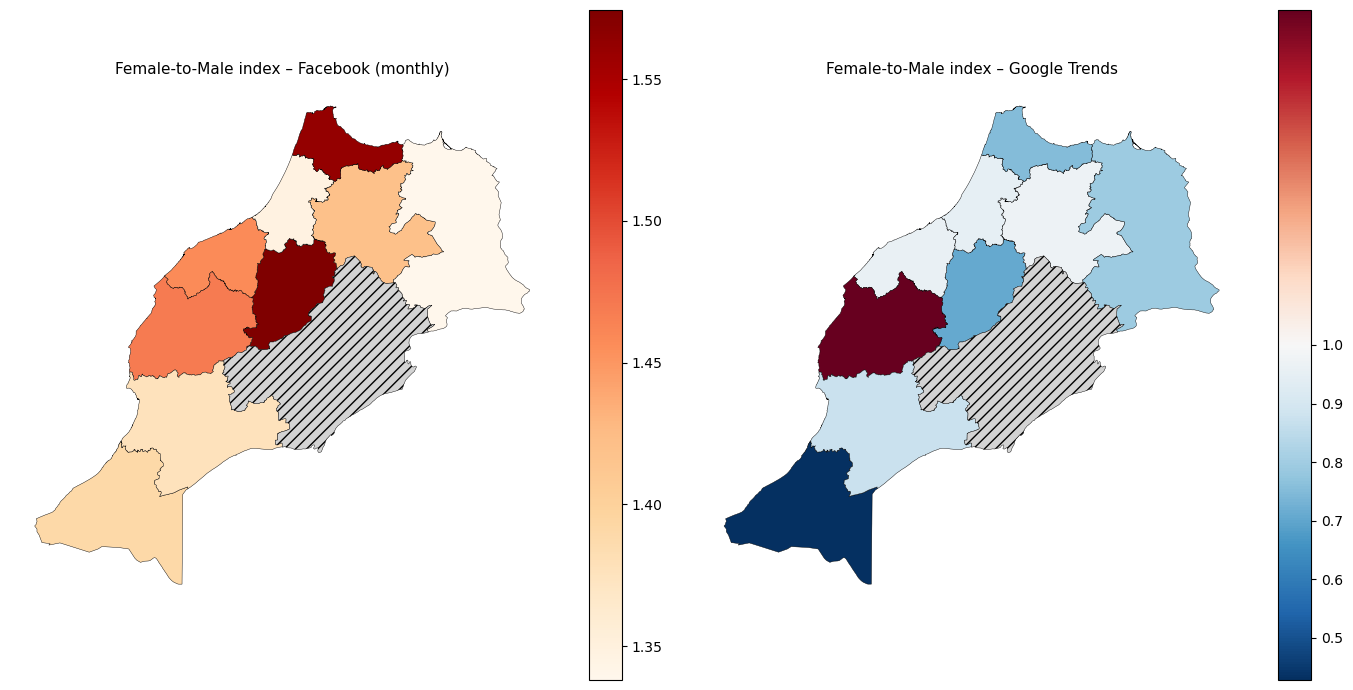

Saving smoothed internet index map to: /home/alina/DPA/P143-UN-WOMEN-big-data-gender-and-the-sdgs-morocco/DIGITAL_GENDER/results/map_internet_smoothed.png


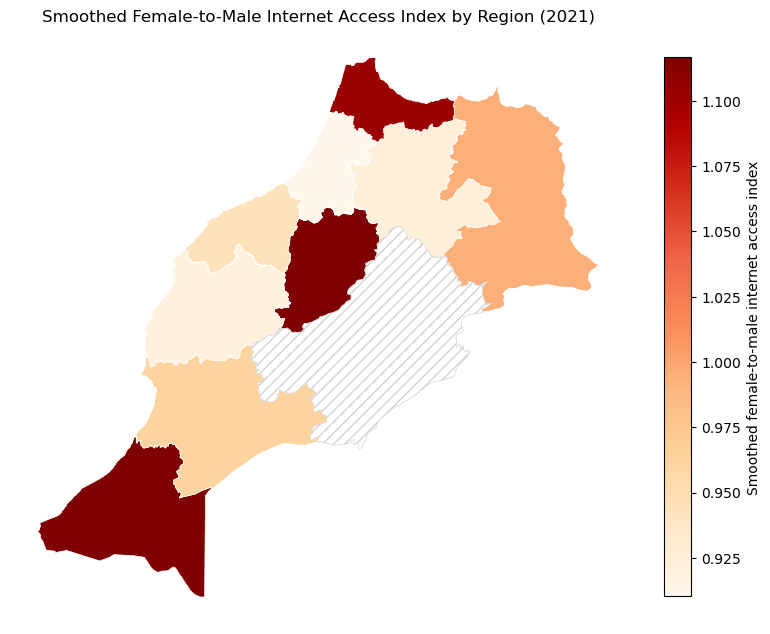

Saving smoothed mobile index map to: /home/alina/DPA/P143-UN-WOMEN-big-data-gender-and-the-sdgs-morocco/DIGITAL_GENDER/results/map_mobile_smoothed.png


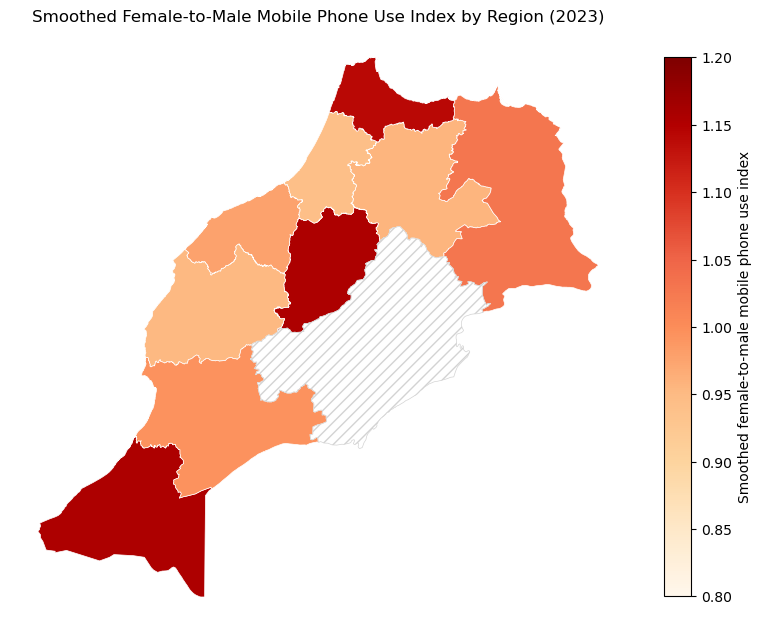

In [11]:
import sys
sys.path.append("scripts")

from plot_gddi_maps import (
    load_gdf_for_maps,
    plot_fb_vs_trends,
    plot_smoothed_internet_index,
    plot_smoothed_mobile_index,
)

# 1. Cargar gdf ya mergeado (GeoJSON + CSV de índices)
gdf = load_gdf_for_maps()

# 2. Dibujar y guardar mapa Facebook vs Trends
plot_fb_vs_trends(gdf)

# 3. Dibujar y guardar mapa de internet suavizado
plot_smoothed_internet_index(gdf)

# 4. Dibujar y guardar mapa de móvil suavizado
#    (recalcula o importa mobile_fm_ratio_national si lo necesitas)
mobile_fm_ratio_national = 1.0  # aquí pones el valor real que ya calculaste
plot_smoothed_mobile_index(gdf, mobile_fm_ratio_national)
